In [38]:
import numpy as np
import matplotlib.pyplot as plt

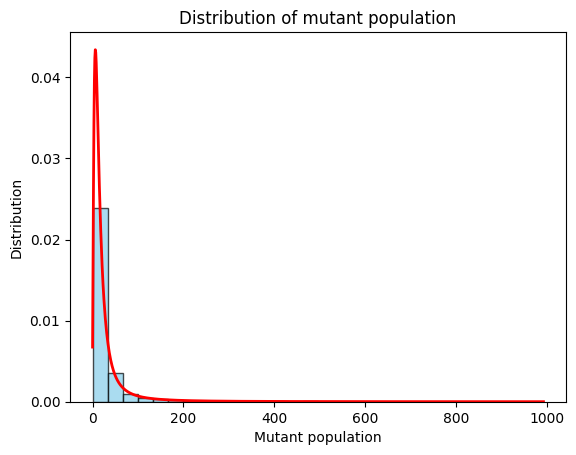

In [39]:
#np.random.seed(42)
mu=5*1e-3 #5*1e-2                           #1e-7 too low to see an effect in such "small" max population (referred to 1e4).
r=1
Nmax=1e3  #1e4                              #1e7 too high to run with this algorithm
nsim=10000
react=[(1-mu)*r,mu*r,r]
p=[0.0]*3
p_T=0
N_mut_end=[]

for sim in range(nsim):
    # print('Running simulation number '+str(sim))
    t=0
    N=[1,0]

    while sum(N)<Nmax:
        p[0]=react[0]*N[0]
        p[1]=react[1]*N[0]
        p[2]=react[2]*N[1]
        p_T=sum(p)

        x=np.random.uniform(0,1)
        ts=-np.log(x)/p_T
        t+=ts

        y=np.random.uniform(0,1)
        p_curr=0
        for i in range(len(react)):
            p_curr+=p[i]
            if y<p_curr/p_T:
                if i == 0:
                    N[0]+=1 # Wt duplicates
                elif i == 1:
                    N[1]+=1 # Wt duplicates but a mutant is born
                elif i == 2:
                    N[1]+=1 # Mutant duplicates
                break
        
    N_mut_end.append(N[1])

#Theoretical MSS Distribution
m=mu*Nmax #read below
max_k=max(N_mut_end)
mss_probs=np.zeros(max_k + 1)

mss_probs[0]=np.exp(-m)

for k in range(1, max_k+1):
    sum_val=0
    for i in range(k):
        sum_val+=mss_probs[i]/(k-i+1)
    mss_probs[k]=(m/k)*sum_val

x_theory=np.arange(max_k+1)

plt.figure(nsim)
plt.hist(N_mut_end, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.plot(x_theory, mss_probs, 'r-', linewidth=2, markersize=4, label='MSS Theory')
plt.xlabel('Mutant population')
plt.ylabel('Distribution')
plt.title('Distribution of mutant population')
plt.show()

In this setting, we have more reactions that may happen during the simulations. Gillespie Algorithm treats this reaction events (replication and mutation) as probabilistic steps. The reactions are the following:

- Wild Type replication: rate (1−mu)*r.
- Mutation event: rate mu*r.
- Mutant replication: rate r.

In every step, I computed the total propensity (p_T​) of any event occurring. The time to the next event is drawn from an exponential distribution and the specific event is chosen based on its relative probability (p[i]​/p_T​).

The problem specifies N=1e7 and μ=5×1e−7, yielding m=5. To simulate this efficiently without running 1e7 loops, I scaled the parameters by decreasing N and increasing mu by the same order of magnitude (N=1e3, mu=5×1e−3), keeping the exponents equal but with opposite sign such that we mantain m=mu*Nmax=5. This produces a situation where simulation with late mutations have zero or few mutants, but rare early mutations cause massive "jackpots".
In fact, as we can see in the first histogram above, we compare the simulated results with the theoretical Ma-Sandri-Sarkar (MSS) distribution. Unlike a Poisson distribution where variance equals the mean, this distribution has a very large variance (variance ≫ mean) and we can observe two main features:

- A significant portion of simulations end with zero or very few mutants. This represents populations where mutations occurred very late or not at all.

- There is a "tail" extending to the right. These are the "jackpot" events. If a mutation occurs early in the exponential growth, that single mutant and its descendants continue to divide, resulting in a massive number of mutants by the time saturation (Nmax​) is reached.

This "Jackpot" effect verifies the Luria-Delbrück hypothesis: mutations arise randomly in the absence of selection pressure, and their final abundance depends heavily on when they occurred during the population's history. The alignment between the simulation (blue bars) and the MSS theory (red line) confirms the validity of what we have discussed.


While biologically accurate, this makes the linear plot difficult to read, as most data are crushed to the left, with a quite invisible tail to the right. To make the distribution graph more understandable and to show better the agreement between the simulation and the MSS theory, I chose to modify the parameters to N=1e4 and mu=5*1e−2. This results in m=500. At this higher mutation rate, the "jackpot" effect is smoothed out, and the distribution is more similar to a Gaussian-like curve (but it is not!). This allows a much clearer visual comparison between the histogram and the theoretical curve in the linear plot.

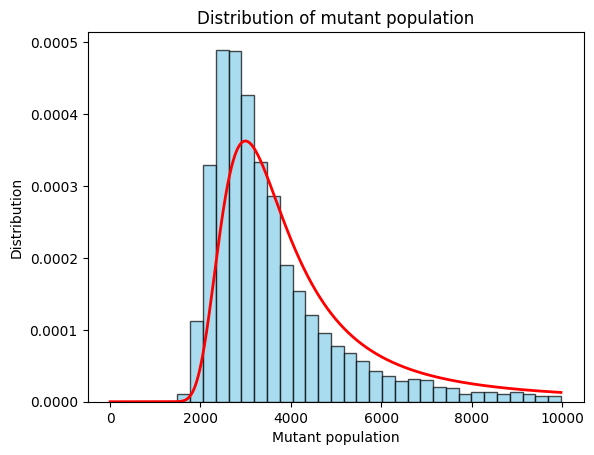